# Coinbase Bazaar x402 Discovery — Exploratory Data Analysis

Analyzing **12,571 endpoints** and **~12,800 payment options** crawled from the Bazaar discovery API.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from collections import Counter
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\yaman\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\yaman\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\yaman\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", 

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\yaman\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\yaman\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\yaman\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", 

AttributeError: _ARRAY_API not found

## 1. Data Loading & Overview

In [2]:
conn = psycopg2.connect(
    host='localhost',
    port=5433,
    dbname='agora',
    user='agora',
    password='agora'
)

endpoints = pd.read_sql('SELECT * FROM endpoints', conn)
payment_options = pd.read_sql('SELECT * FROM payment_options', conn)
crawl_runs = pd.read_sql('SELECT * FROM crawl_runs', conn)

print(f'Endpoints:        {len(endpoints):,}')
print(f'Payment Options:  {len(payment_options):,}')
print(f'Crawl Runs:       {len(crawl_runs):,}')

Endpoints:        12,571
Payment Options:  12,803
Crawl Runs:       6


In [3]:
print('=== Endpoints Schema ===')
print(endpoints.dtypes)
print(f'\nNull counts:\n{endpoints.isnull().sum()[endpoints.isnull().sum() > 0]}')
print(f'\n=== Payment Options Schema ===')
print(payment_options.dtypes)
print(f'\nNull counts:\n{payment_options.isnull().sum()[payment_options.isnull().sum() > 0]}')

=== Endpoints Schema ===
id                            object
resource_url                  object
domain                        object
type                          object
x402_version                   int64
description                   object
http_method                   object
input_schema                  object
output_schema                 object
raw_metadata                  object
last_updated     datetime64[ns, UTC]
first_seen       datetime64[ns, UTC]
last_crawled     datetime64[ns, UTC]
embedding                     object
dtype: object

Null counts:
input_schema        63
output_schema    11259
raw_metadata      1294
embedding        12571
dtype: int64

=== Payment Options Schema ===
id                      object
endpoint_id             object
scheme                  object
network_raw             object
network_normalized      object
asset_address           object
asset_name              object
max_amount_raw          object
price_usd              float64
pay_to       

In [4]:
endpoints.head(3)

,id,resource_url,domain,type,x402_version,description,http_method,input_schema,output_schema,raw_metadata,last_updated,first_seen,last_crawled,embedding
0,bead003b-632c-4113-82c6-b0a30d351ca1,https://public.zapper.xyz/x402/search,public.zapper.xyz,http,1,"Search for ERC20 tokens, NFTs, Users, Apps, or...",POST,"{'type': 'http', 'method': 'POST', 'bodyType':...",{'data': {'searchV2': {'results': {'type': 'ar...,{},2026-02-23 03:48:03.935000+00:00,2026-02-23 04:10:08.342307+00:00,2026-02-23 04:11:13.839676+00:00,None
1,a918da69-2fc3-44b8-814c-13dbeb237dbb,https://public.zapper.xyz/x402/nft-ranking,public.zapper.xyz,http,1,Get a ranked list of NFT collections based on ...,POST,"{'type': 'http', 'method': 'POST', 'bodyType':...","{'data': {'nftRanking': {'type': 'object', 'pr...",{},2026-02-23 03:47:54.371000+00:00,2026-02-23 04:10:08.352296+00:00,2026-02-23 04:11:13.849596+00:00,None
2,6032bb8e-a494-40c1-baa8-fad440168b9f,https://public.zapper.xyz/x402/account-identity,public.zapper.xyz,http,1,"Get social identity (ENS, Farcaster, Lens, Bas...",POST,"{'type': 'http', 'method': 'POST', 'bodyType':...","{'data': {'account': {'type': 'object', 'prope...",{},2026-02-23 03:47:45.671000+00:00,2026-02-23 04:10:08.361208+00:00,2026-02-23 04:11:13.858143+00:00,None


In [5]:
payment_options.head(3)

,id,endpoint_id,scheme,network_raw,network_normalized,asset_address,asset_name,max_amount_raw,price_usd,pay_to,max_timeout_seconds,mime_type,description,output_schema_raw
0,5ab1b27f-d8cb-48f0-94bf-618853738015,fca0c303-fad8-416b-9463-be8e1a7ebff4,exact,base,base,0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913,USD Coin,10000,0.01,0x1A2B13E97f5F837C8F9FA1F95a1484B7C70d85F3,300,application/json,Premium API Access,"{'input': {'type': 'http', 'method': 'GET', 'd..."
1,23500384-4655-4b47-ae07-0d941fa45ad2,5f286885-ea48-434a-a852-bb9a1261da0f,exact,base,base,0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913,USD Coin,10000,0.01,0x1A2B13E97f5F837C8F9FA1F95a1484B7C70d85F3,300,application/json,Premium API Access,"{'input': {'type': 'http', 'method': 'GET', 'd..."
2,04ebdeb7-12fd-42d7-9cd3-b011b52ea234,41cb3f6c-9b97-4357-8014-4f5932a542c0,exact,base,base,0x833589fCD6eDb6E08f4c7C32D4f71b54bdA02913,USD Coin,10000,0.01,0x1A2B13E97f5F837C8F9FA1F95a1484B7C70d85F3,300,application/json,Premium API Access,"{'input': {'type': 'http', 'method': 'GET', 'd..."


## 2. Provider Landscape

Total unique domains: 455

Top 20 domains by endpoint count:


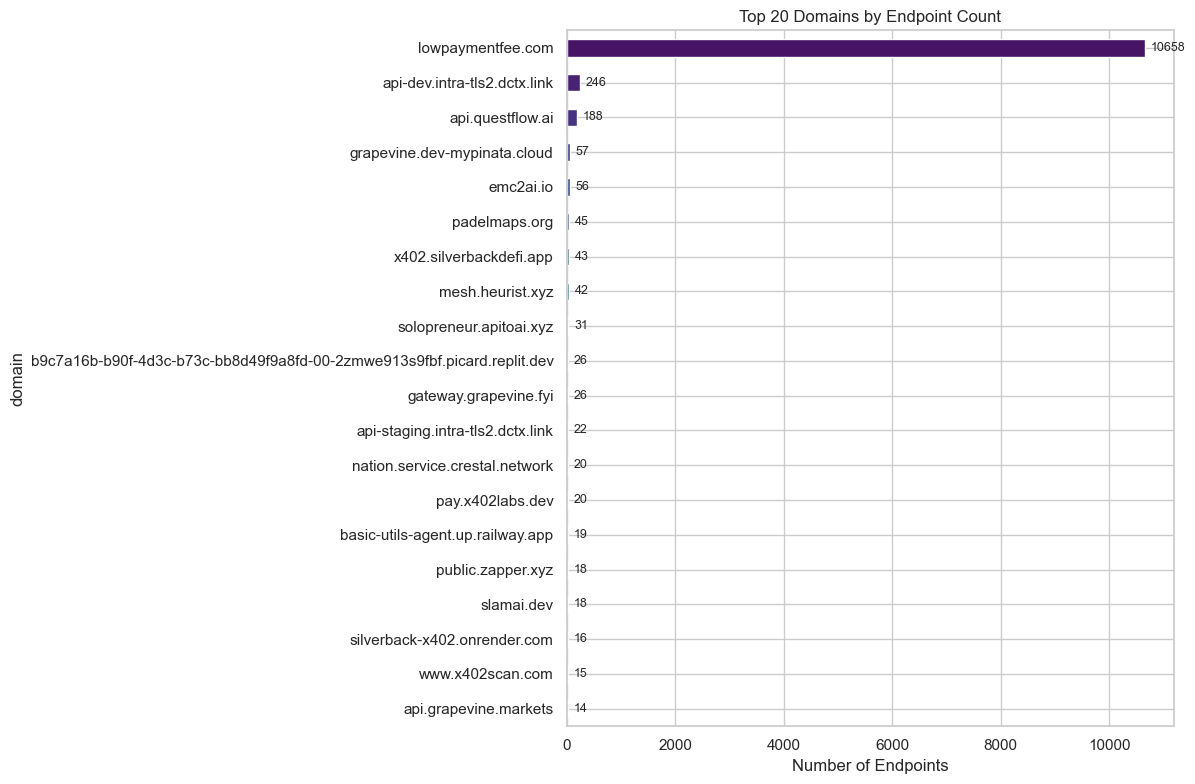

In [6]:
domain_counts = endpoints['domain'].value_counts()
print(f'Total unique domains: {len(domain_counts)}')
print(f'\nTop 20 domains by endpoint count:')

fig, ax = plt.subplots(figsize=(12, 8))
top20 = domain_counts.head(20)
top20.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(top20)))
ax.set_xlabel('Number of Endpoints')
ax.set_title('Top 20 Domains by Endpoint Count')
ax.invert_yaxis()
for i, v in enumerate(top20.values):
    ax.text(v + max(top20.values)*0.01, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

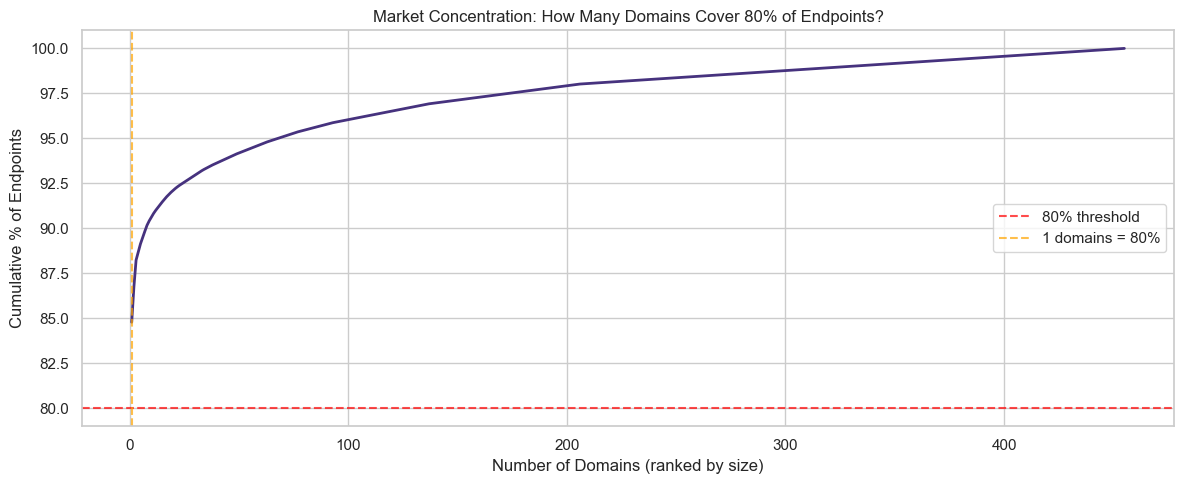

1 domains account for 80% of all endpoints
Top domain alone: 10,658 endpoints (84.8%)


In [7]:
cumulative = domain_counts.cumsum() / domain_counts.sum() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(cumulative)+1), cumulative.values, linewidth=2)
ax.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% threshold')

domains_for_80 = (cumulative <= 80).sum() + 1
ax.axvline(x=domains_for_80, color='orange', linestyle='--', alpha=0.7, label=f'{domains_for_80} domains = 80%')

ax.set_xlabel('Number of Domains (ranked by size)')
ax.set_ylabel('Cumulative % of Endpoints')
ax.set_title('Market Concentration: How Many Domains Cover 80% of Endpoints?')
ax.legend()
plt.tight_layout()
plt.show()

print(f'{domains_for_80} domains account for 80% of all endpoints')
print(f'Top domain alone: {domain_counts.iloc[0]:,} endpoints ({domain_counts.iloc[0]/len(endpoints)*100:.1f}%)')

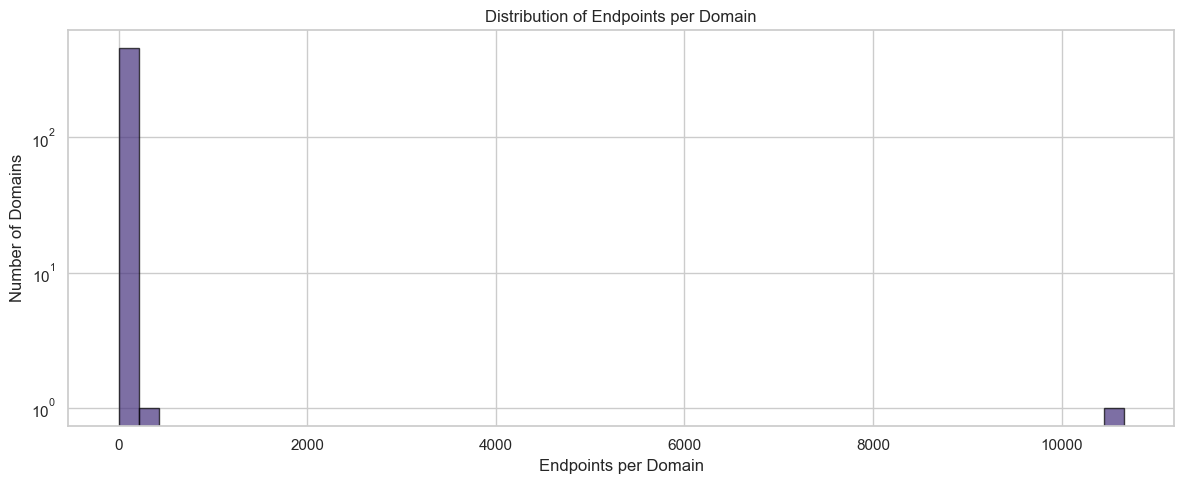

Median endpoints per domain: 1
Mean endpoints per domain:   27.6
Domains with just 1 endpoint: 249


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
domain_counts.plot(kind='hist', bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Endpoints per Domain')
ax.set_ylabel('Number of Domains')
ax.set_title('Distribution of Endpoints per Domain')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f'Median endpoints per domain: {domain_counts.median():.0f}')
print(f'Mean endpoints per domain:   {domain_counts.mean():.1f}')
print(f'Domains with just 1 endpoint: {(domain_counts == 1).sum()}')

## 3. Network & Chain Analysis

Unique networks: 5


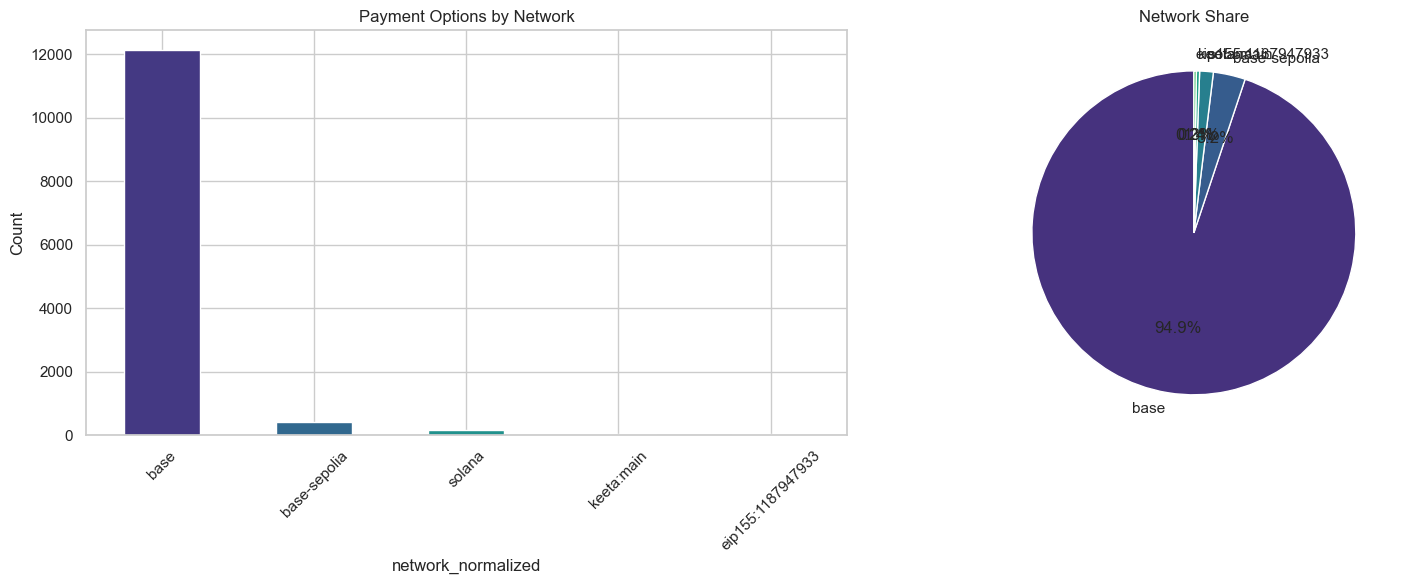

In [9]:
network_counts = payment_options['network_normalized'].value_counts()
print(f'Unique networks: {len(network_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
network_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', len(network_counts)))
axes[0].set_title('Payment Options by Network')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
top_networks = network_counts.head(8)
if len(network_counts) > 8:
    other = network_counts.iloc[8:].sum()
    top_networks = pd.concat([top_networks, pd.Series({'Other': other})])
top_networks.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Network Share')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

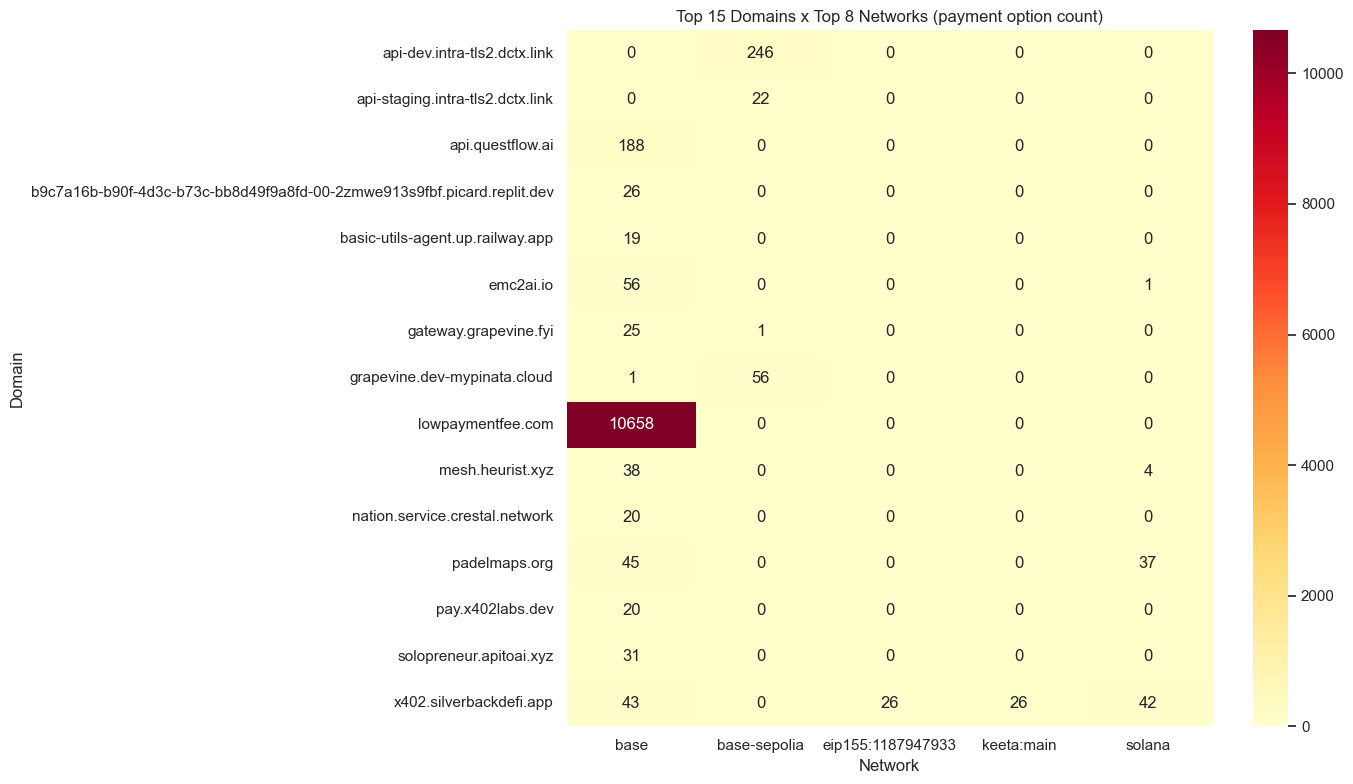

In [10]:
# Merge to get domain info for each payment option
merged = payment_options.merge(endpoints[['id', 'domain']], left_on='endpoint_id', right_on='id', suffixes=('', '_ep'))

top_domains_list = domain_counts.head(15).index.tolist()
top_networks_list = network_counts.head(8).index.tolist()

filtered = merged[merged['domain'].isin(top_domains_list) & merged['network_normalized'].isin(top_networks_list)]
heatmap_data = filtered.groupby(['domain', 'network_normalized']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Top 15 Domains x Top 8 Networks (payment option count)')
ax.set_xlabel('Network')
ax.set_ylabel('Domain')
plt.tight_layout()
plt.show()

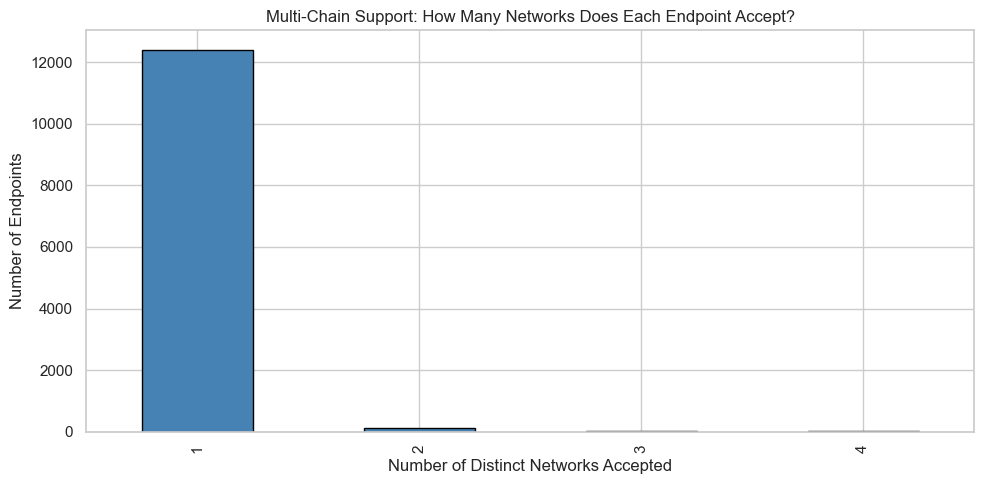

Endpoints accepting only 1 network: 12,413
Endpoints accepting 2+ networks:    158
Max networks for a single endpoint:  4


In [11]:
networks_per_endpoint = payment_options.groupby('endpoint_id')['network_normalized'].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
networks_per_endpoint.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Distinct Networks Accepted')
ax.set_ylabel('Number of Endpoints')
ax.set_title('Multi-Chain Support: How Many Networks Does Each Endpoint Accept?')
plt.tight_layout()
plt.show()

print(f'Endpoints accepting only 1 network: {(networks_per_endpoint == 1).sum():,}')
print(f'Endpoints accepting 2+ networks:    {(networks_per_endpoint >= 2).sum():,}')
print(f'Max networks for a single endpoint:  {networks_per_endpoint.max()}')

## 4. Pricing Deep-Dive

In [12]:
prices = payment_options['price_usd'].astype(float)

print(f'Price statistics (USD):')
print(f'  Min:    ${prices.min():.6f}')
print(f'  Median: ${prices.median():.6f}')
print(f'  Mean:   ${prices.mean():.6f}')
print(f'  Max:    ${prices.max():.2f}')
print(f'  Std:    ${prices.std():.6f}')
print(f'\nFree (price=0): {(prices == 0).sum():,} ({(prices == 0).mean()*100:.1f}%)')
print(f'Paid (price>0): {(prices > 0).sum():,} ({(prices > 0).mean()*100:.1f}%)')

Price statistics (USD):
  Min:    $0.000000
  Median: $0.010000
  Mean:   $15.986649
  Max:    $100000.00
  Std:    $1249.880172

Free (price=0): 109 (0.9%)
Paid (price>0): 12,694 (99.1%)


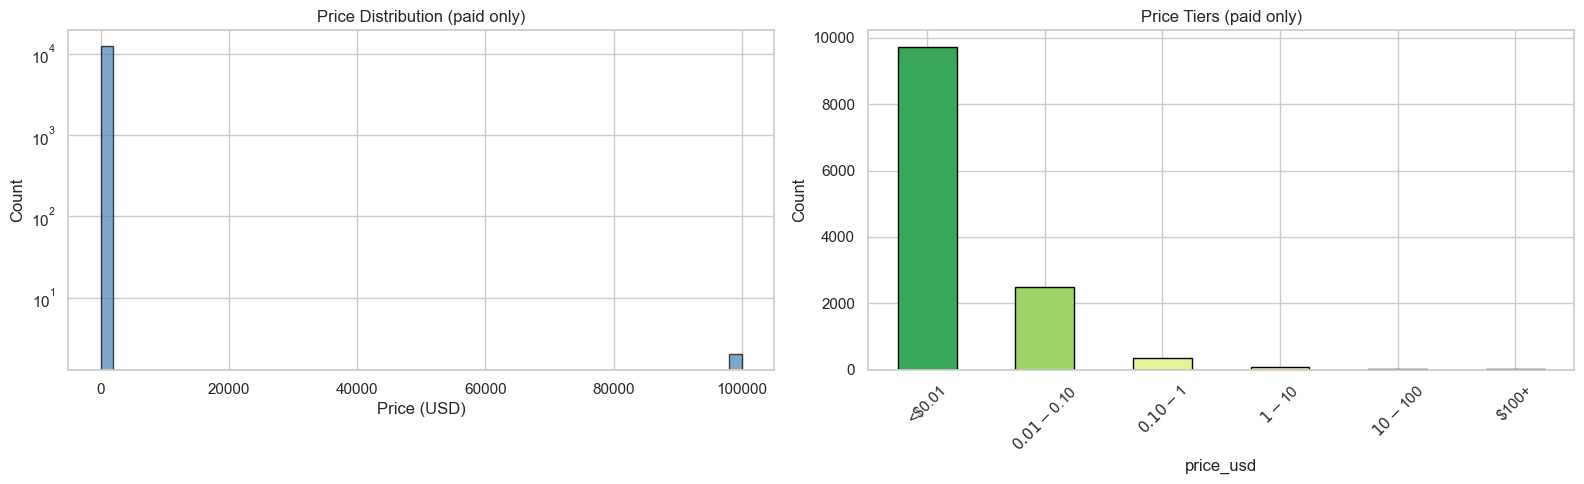

In [13]:
paid_prices = prices[prices > 0]

if len(paid_prices) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Log-scale histogram of paid prices
    axes[0].hist(paid_prices, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Price (USD)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Price Distribution (paid only)')
    axes[0].set_yscale('log')

    # Price tiers
    tiers = pd.cut(paid_prices, bins=[0, 0.01, 0.1, 1, 10, 100, float('inf')],
                   labels=['<$0.01', '$0.01-$0.10', '$0.10-$1', '$1-$10', '$10-$100', '$100+'])
    tier_counts = tiers.value_counts().sort_index()
    tier_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('RdYlGn_r', len(tier_counts)), edgecolor='black')
    axes[1].set_title('Price Tiers (paid only)')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print('All payment options are free (price_usd = 0)')

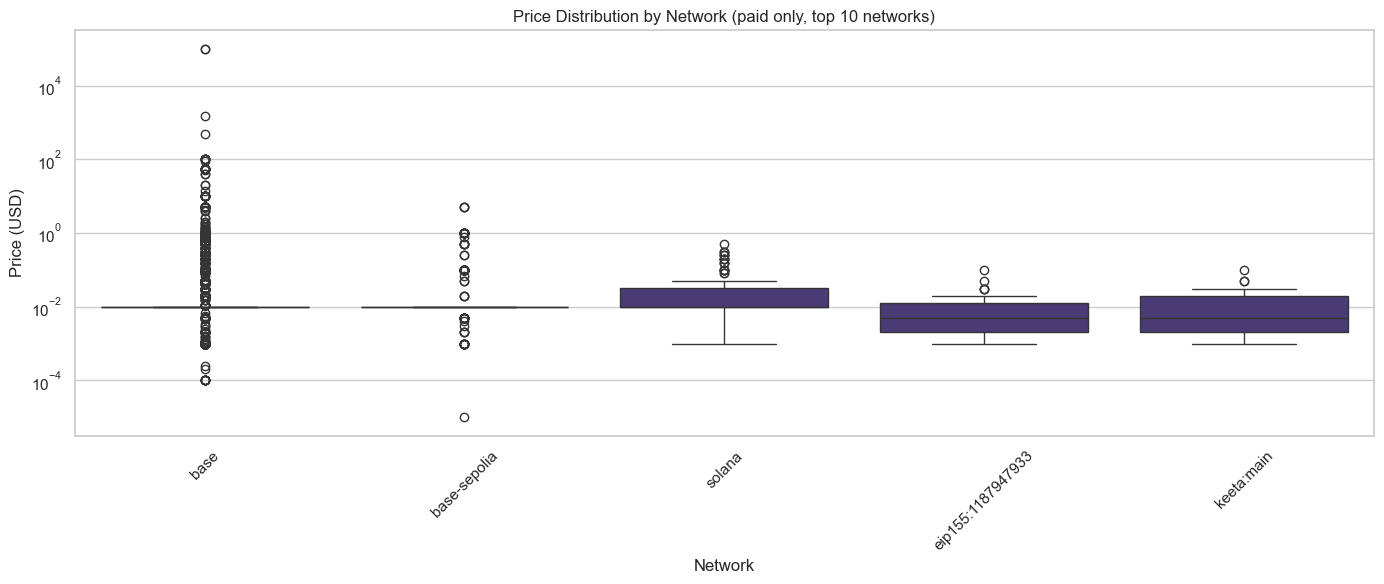

In [14]:
paid_options = payment_options[prices > 0].copy()
paid_options['price_usd'] = paid_options['price_usd'].astype(float)

if len(paid_options) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    networks_with_paid = paid_options.groupby('network_normalized')['price_usd'].median().sort_values(ascending=False)
    order = networks_with_paid.index.tolist()
    sns.boxplot(data=paid_options[paid_options['network_normalized'].isin(order[:10])],
                x='network_normalized', y='price_usd', order=order[:10], ax=ax)
    ax.set_title('Price Distribution by Network (paid only, top 10 networks)')
    ax.set_xlabel('Network')
    ax.set_ylabel('Price (USD)')
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('All payment options are free')

In [15]:
if len(paid_options) > 0:
    top_expensive = paid_options.nlargest(10, 'price_usd')[['endpoint_id', 'network_normalized', 'asset_name', 'price_usd']]
    top_expensive = top_expensive.merge(endpoints[['id', 'domain', 'resource_url']], left_on='endpoint_id', right_on='id')
    print('Top 10 Most Expensive Payment Options:')
    display(top_expensive[['domain', 'resource_url', 'network_normalized', 'asset_name', 'price_usd']])
else:
    print('All free')

Top 10 Most Expensive Payment Options:


,domain,resource_url,network_normalized,asset_name,price_usd
0,api.compute3.ai,http://api.compute3.ai/api/x402/top_up,base,USD Coin,100000.0
1,dev-api.hypercli.com,http://dev-api.hypercli.com/api/x402/top_up,base,USD Coin,100000.0
2,pay.codenut.ai,https://pay.codenut.ai/x402/0x5e04D4bC0A077c27...,base,USD Coin,1478.0
3,www.samragsdale.com,https://www.samragsdale.com/api/x402/calendar,base,USD Coin,500.0
4,www.qrbase.xyz,https://www.qrbase.xyz/api/x402/ping100,base,USD Coin,100.0
5,xtux402.vercel.app,https://xtux402.vercel.app/mint-v3,base,USD Coin,100.0
6,pay.codenut.ai,https://pay.codenut.ai/credit-drop/xl,base,USD Coin,100.0
7,nut402.codenut.xyz,https://nut402.codenut.xyz/api/mint/xl,base,USD Coin,100.0
8,x402v2.vercel.app,https://x402v2.vercel.app/payment/100usdc,base,USD Coin,100.0
9,payx402.fun,https://payx402.fun/payment/100usdc,base,USD Coin,100.0


## 5. Endpoint Characteristics

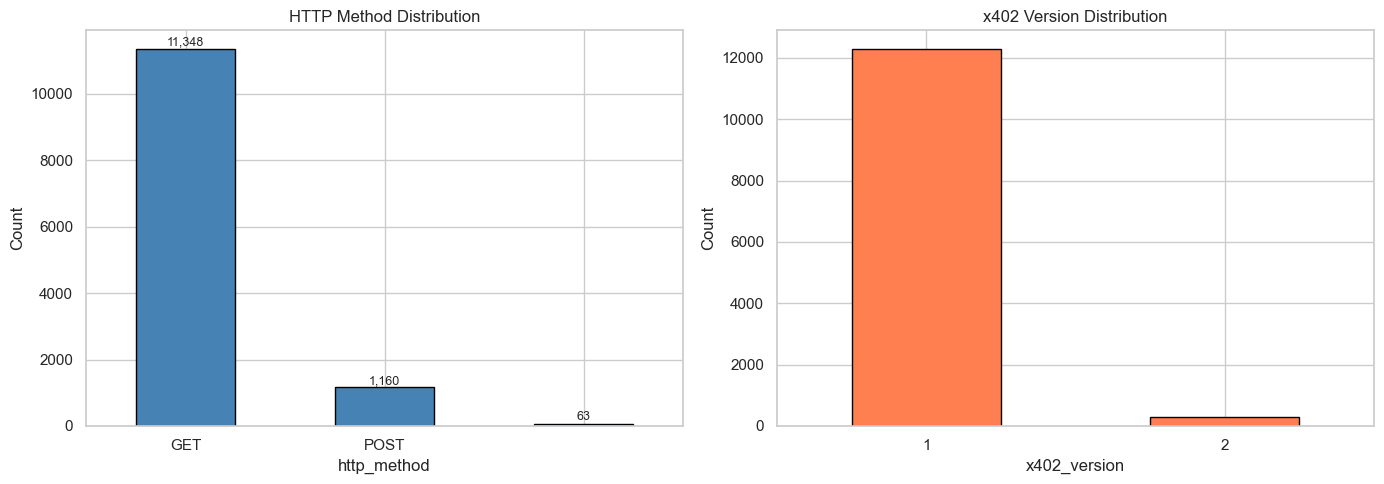

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HTTP Method distribution
method_counts = endpoints['http_method'].value_counts()
method_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('HTTP Method Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(method_counts.values):
    axes[0].text(i, v + max(method_counts.values)*0.01, f'{v:,}', ha='center', fontsize=9)

# x402 version distribution
version_counts = endpoints['x402_version'].value_counts().sort_index()
version_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('x402 Version Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

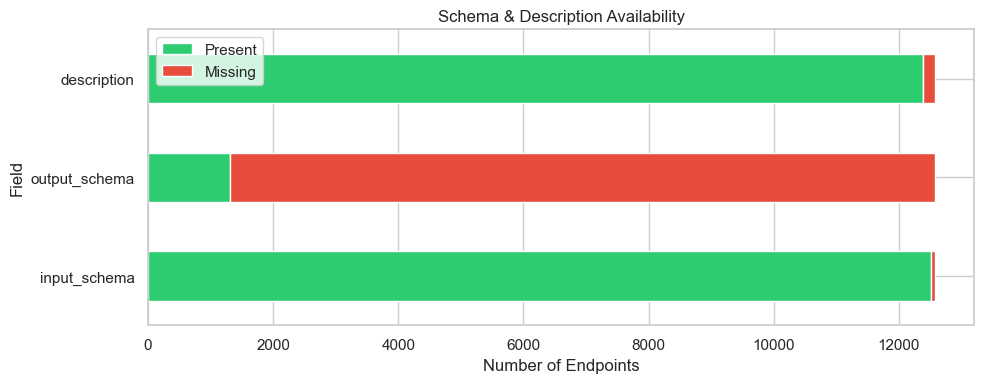

Has input_schema:  12,508 (99.5%)
Has output_schema: 1,312 (10.4%)
Has description:   12,384 (98.5%)


In [17]:
has_input = endpoints['input_schema'].notna().sum()
has_output = endpoints['output_schema'].notna().sum()
has_description = (endpoints['description'] != '').sum()

schema_data = pd.DataFrame({
    'Field': ['input_schema', 'output_schema', 'description'],
    'Present': [has_input, has_output, has_description],
    'Missing': [len(endpoints)-has_input, len(endpoints)-has_output, len(endpoints)-has_description]
})

fig, ax = plt.subplots(figsize=(10, 4))
schema_data.set_index('Field')[['Present', 'Missing']].plot(kind='barh', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Schema & Description Availability')
ax.set_xlabel('Number of Endpoints')
plt.tight_layout()
plt.show()

print(f'Has input_schema:  {has_input:,} ({has_input/len(endpoints)*100:.1f}%)')
print(f'Has output_schema: {has_output:,} ({has_output/len(endpoints)*100:.1f}%)')
print(f'Has description:   {has_description:,} ({has_description/len(endpoints)*100:.1f}%)')

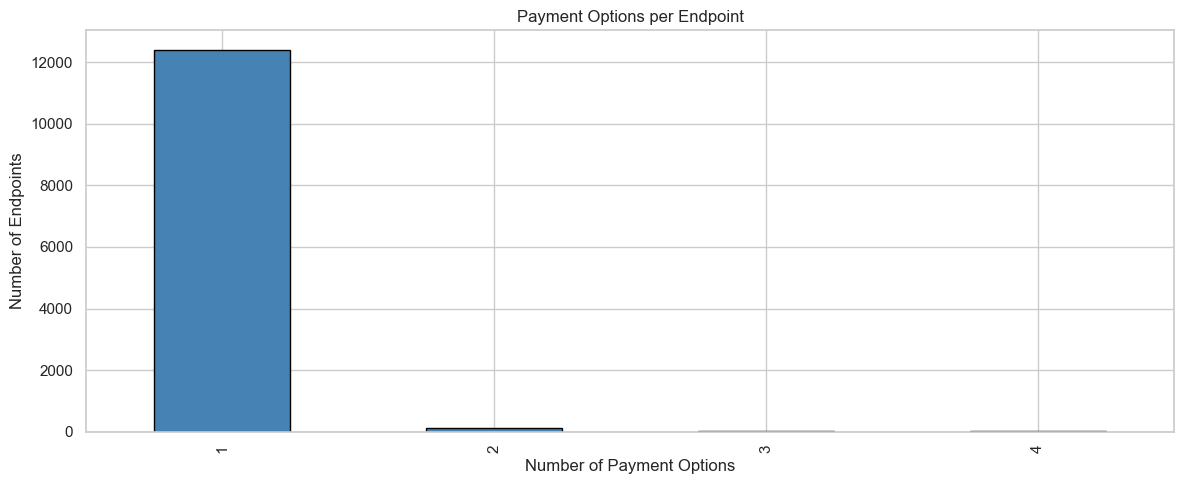

Min payment options:    1
Median payment options: 1
Mean payment options:   1.0
Max payment options:    4


In [18]:
po_per_endpoint = payment_options.groupby('endpoint_id').size()

fig, ax = plt.subplots(figsize=(12, 5))
po_per_endpoint.value_counts().sort_index().head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Payment Options')
ax.set_ylabel('Number of Endpoints')
ax.set_title('Payment Options per Endpoint')
plt.tight_layout()
plt.show()

print(f'Min payment options:    {po_per_endpoint.min()}')
print(f'Median payment options: {po_per_endpoint.median():.0f}')
print(f'Mean payment options:   {po_per_endpoint.mean():.1f}')
print(f'Max payment options:    {po_per_endpoint.max()}')

## 6. Asset Analysis

Unique assets: 3


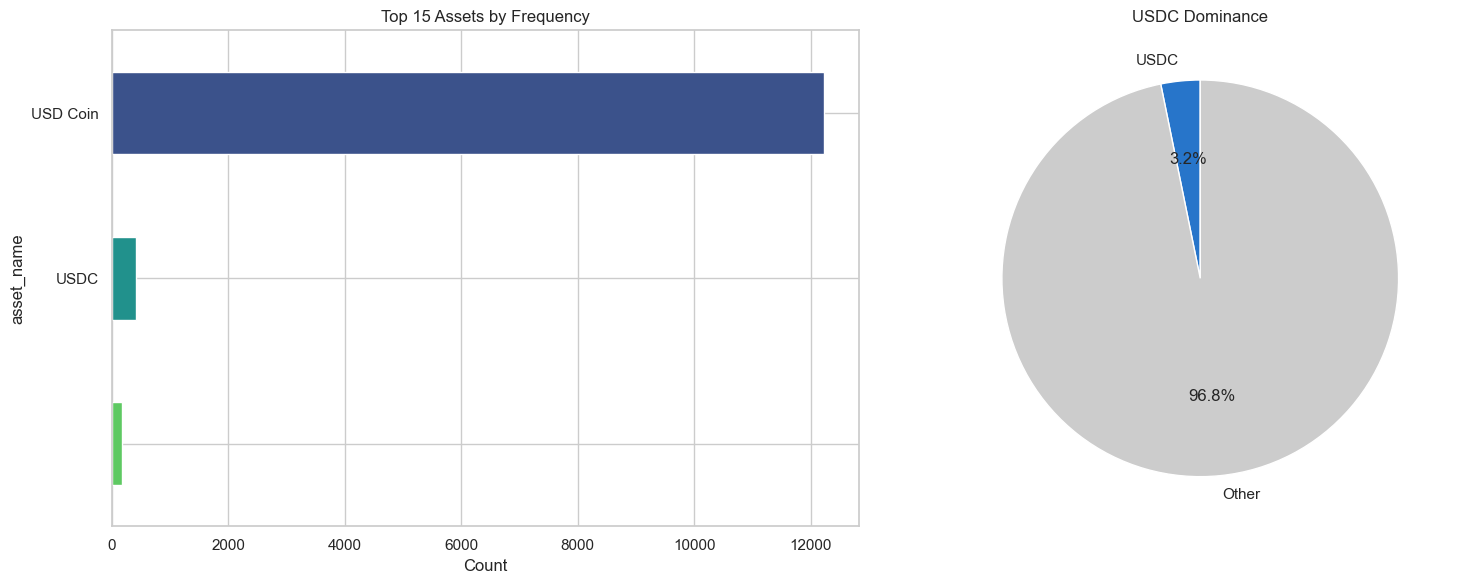

In [19]:
asset_counts = payment_options['asset_name'].value_counts()
print(f'Unique assets: {len(asset_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top assets bar chart
top_assets = asset_counts.head(15)
top_assets.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(top_assets)))
axes[0].set_title('Top 15 Assets by Frequency')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# USDC dominance
usdc_count = asset_counts.get('USDC', 0)
other_count = len(payment_options) - usdc_count
axes[1].pie([usdc_count, other_count], labels=['USDC', 'Other'], autopct='%1.1f%%',
            colors=['#2775ca', '#cccccc'], startangle=90)
axes[1].set_title('USDC Dominance')

plt.tight_layout()
plt.show()

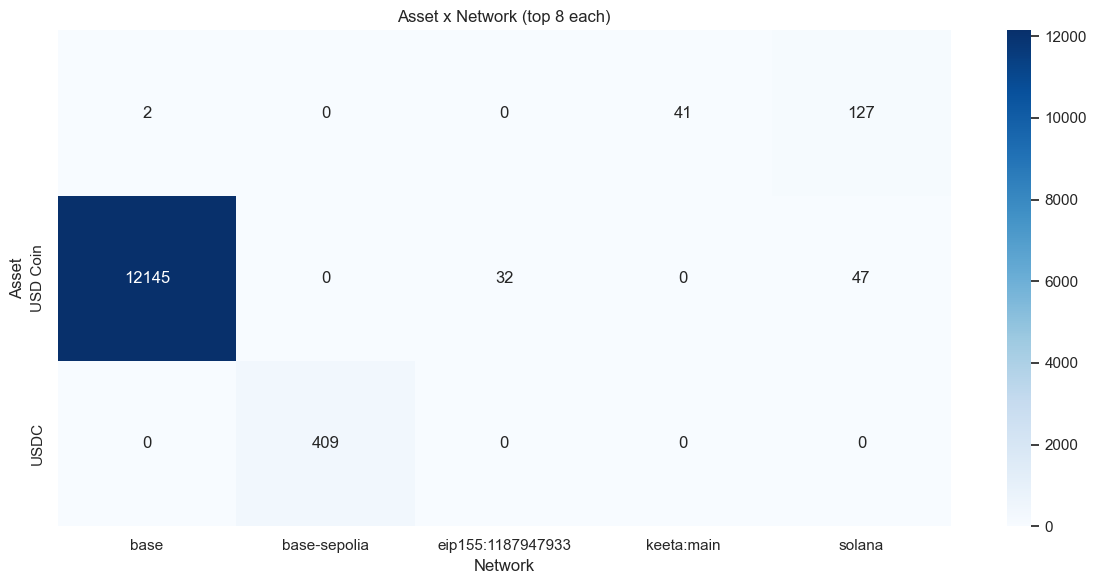

In [20]:
top_assets_list = asset_counts.head(8).index.tolist()

filtered_po = payment_options[
    payment_options['asset_name'].isin(top_assets_list) &
    payment_options['network_normalized'].isin(top_networks_list)
]

crosstab = pd.crosstab(filtered_po['asset_name'], filtered_po['network_normalized'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Asset x Network (top 8 each)')
ax.set_xlabel('Network')
ax.set_ylabel('Asset')
plt.tight_layout()
plt.show()

## Summary & Key Findings

In [21]:
print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print(f'\nDataset: {len(endpoints):,} endpoints, {len(payment_options):,} payment options')
print(f'Unique domains:  {endpoints["domain"].nunique()}')
print(f'Unique networks: {payment_options["network_normalized"].nunique()}')
print(f'Unique assets:   {payment_options["asset_name"].nunique()}')

print(f'\n--- Provider Concentration ---')
print(f'Top domain: {domain_counts.index[0]} ({domain_counts.iloc[0]:,} endpoints, {domain_counts.iloc[0]/len(endpoints)*100:.1f}%)')
print(f'Domains for 80% coverage: {domains_for_80}')

print(f'\n--- Networks ---')
print(f'Top network: {network_counts.index[0]} ({network_counts.iloc[0]:,} payment options, {network_counts.iloc[0]/len(payment_options)*100:.1f}%)')

print(f'\n--- Pricing ---')
free_pct = (prices == 0).mean() * 100
print(f'Free endpoints: {free_pct:.1f}%')
if len(paid_prices) > 0:
    print(f'Median paid price: ${paid_prices.median():.6f}')

print(f'\n--- Assets ---')
usdc_pct = usdc_count / len(payment_options) * 100
print(f'USDC dominance: {usdc_pct:.1f}%')

conn.close()
print(f'\n{"=" * 60}')
print('Connection closed.')

KEY FINDINGS

Dataset: 12,571 endpoints, 12,803 payment options
Unique domains:  455
Unique networks: 5
Unique assets:   3

--- Provider Concentration ---
Top domain: lowpaymentfee.com (10,658 endpoints, 84.8%)
Domains for 80% coverage: 1

--- Networks ---
Top network: base (12,147 payment options, 94.9%)

--- Pricing ---
Free endpoints: 0.9%
Median paid price: $0.010000

--- Assets ---
USDC dominance: 3.2%

Connection closed.
